In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

def create_sparse_toy_data(n_samples=1000, n_features=20):
    """
    Create toy data where only 2-3 features are truly important,
    and these important features are sparse (mostly zero).
    """
    X = torch.zeros(n_samples, n_features)
    
    # Feature 1: Very sparse but highly predictive (appears in 5% of samples)
    sparse_mask_1 = torch.rand(n_samples) < 0.05
    X[sparse_mask_1, 0] = torch.randn(sparse_mask_1.sum()) * 3
    
    # Feature 2: Moderately sparse but important (appears in 15% of samples)
    sparse_mask_2 = torch.rand(n_samples) < 0.15
    X[sparse_mask_2, 1] = torch.randn(sparse_mask_2.sum()) * 2
    
    # Features 3-5: Dense but less important (noise features)
    X[:, 2:5] = torch.randn(n_samples, 3) * 0.5
    
    # Remaining features: Pure noise
    X[:, 5:] = torch.randn(n_samples, n_features-5) * 0.1
    
    # Create target: heavily dependent on sparse features
    y = (2.0 * X[:, 0] +           # Sparse feature 1 (high weight)
         1.5 * X[:, 1] +           # Sparse feature 2 (medium weight)
         0.3 * X[:, 2:5].sum(dim=1) +  # Dense features (low weight)
         torch.randn(n_samples) * 0.1)  # Small noise
    
    # Convert to binary classification
    y = (y > y.median()).float()
    
    return X, y

# Generate the toy dataset
X_train, y_train = create_sparse_toy_data(n_samples=2000, n_features=20)
X_test, y_test = create_sparse_toy_data(n_samples=500, n_features=20)

print("Dataset characteristics:")
print(f"Feature 0 (very sparse): {(X_train[:, 0] != 0).float().mean():.1%} non-zero")
print(f"Feature 1 (moderately sparse): {(X_train[:, 1] != 0).float().mean():.1%} non-zero")
print(f"Features 2-4 (dense): {(X_train[:, 2:5] != 0).float().mean():.1%} non-zero")


Dataset characteristics:
Feature 0 (very sparse): 4.8% non-zero
Feature 1 (moderately sparse): 14.5% non-zero
Features 2-4 (dense): 100.0% non-zero


In [5]:
class SimpleClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)
        
    def forward(self, x):
        return torch.sigmoid(self.linear(x))

def train_and_compare(X_train, y_train, X_test, y_test, epochs=200):
    """Compare SGD vs Adagrad on the sparse toy problem."""
    
    results = {}
    
    for opt_name in ['SGD', 'Adagrad']:
        # Create fresh model for each optimizer
        model = SimpleClassifier(X_train.shape[1])
        criterion = nn.BCELoss()
        
        # Use same learning rate for fair comparison
        if opt_name == 'SGD':
            optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
        else:
            optimizer = torch.optim.Adagrad(model.parameters(), lr=0.01)
        
        train_losses = []
        test_accuracies = []
        weight_evolution = []  # Track how weights evolve
        
        for epoch in range(epochs):
            # Training
            model.train()
            optimizer.zero_grad()
            y_pred = model(X_train).squeeze()
            loss = criterion(y_pred, y_train)
            loss.backward()
            optimizer.step()
            
            train_losses.append(loss.item())
            
            # Track weight evolution (focus on first 5 features)
            weights = model.linear.weight.data[0, :5].clone()
            weight_evolution.append(weights.numpy())
            
            # Test accuracy every 10 epochs
            if epoch % 10 == 0:
                model.eval()
                with torch.no_grad():
                    test_pred = model(X_test).squeeze()
                    test_acc = ((test_pred > 0.5) == y_test).float().mean()
                    test_accuracies.append(test_acc.item())
        
        results[opt_name] = {
            'train_losses': train_losses,
            'test_accuracies': test_accuracies,
            'final_weights': model.linear.weight.data[0].numpy(),
            'weight_evolution': np.array(weight_evolution)
        }
        
        print(f"{opt_name} - Final test accuracy: {test_accuracies[-1]:.4f}")
        print(f"{opt_name} - Weights for sparse features [0,1]: {model.linear.weight.data[0, :2].numpy()}")
        print(f"{opt_name} - Weights for dense features [2,3,4]: {model.linear.weight.data[0, 2:5].numpy()}")
        print()
    
    return results

# Run the comparison
results = train_and_compare(X_train, y_train, X_test, y_test)


SGD - Final test accuracy: 0.6720
SGD - Weights for sparse features [0,1]: [0.11269801 0.345527  ]
SGD - Weights for dense features [2,3,4]: [ 0.07035098  0.13256487 -0.03054867]

Adagrad - Final test accuracy: 0.8140
Adagrad - Weights for sparse features [0,1]: [0.05876506 0.3554201 ]
Adagrad - Weights for dense features [2,3,4]: [0.414953   0.39506564 0.11743575]



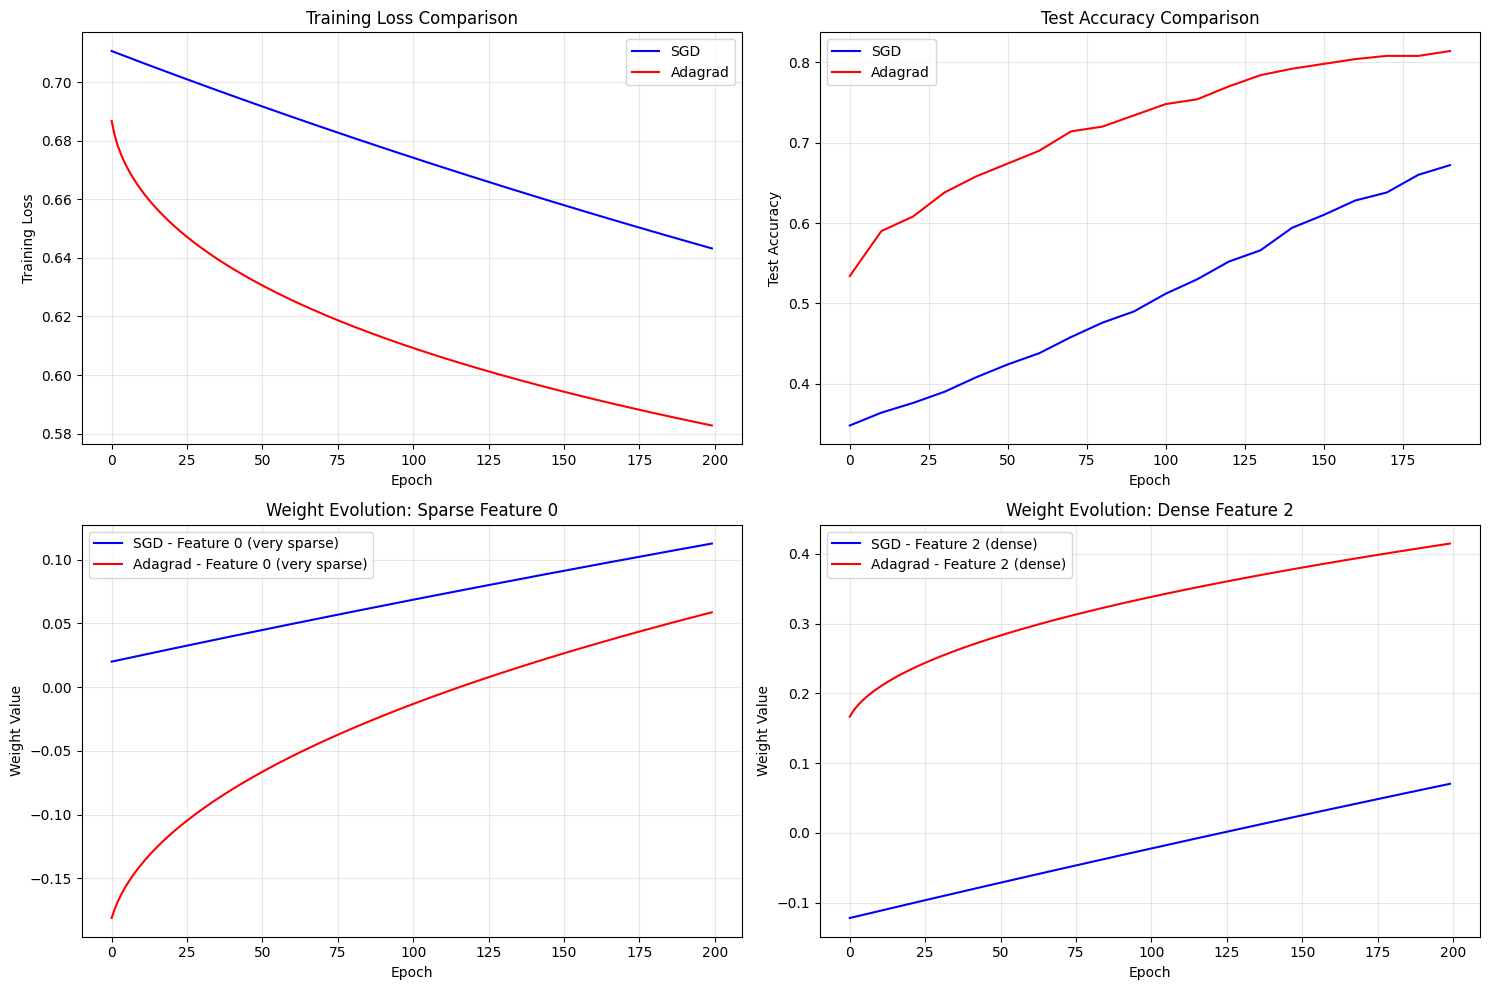

In [6]:
# Plot the results
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Training loss comparison
axes[0, 0].plot(results['SGD']['train_losses'], label='SGD', color='blue')
axes[0, 0].plot(results['Adagrad']['train_losses'], label='Adagrad', color='red')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Training Loss')
axes[0, 0].set_title('Training Loss Comparison')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Test accuracy comparison
test_epochs = list(range(0, 200, 10))
axes[0, 1].plot(test_epochs, results['SGD']['test_accuracies'], label='SGD', color='blue')
axes[0, 1].plot(test_epochs, results['Adagrad']['test_accuracies'], label='Adagrad', color='red')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Test Accuracy')
axes[0, 1].set_title('Test Accuracy Comparison')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Weight evolution for sparse feature 0
axes[1, 0].plot(results['SGD']['weight_evolution'][:, 0], label='SGD - Feature 0 (very sparse)', color='blue')
axes[1, 0].plot(results['Adagrad']['weight_evolution'][:, 0], label='Adagrad - Feature 0 (very sparse)', color='red')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Weight Value')
axes[1, 0].set_title('Weight Evolution: Sparse Feature 0')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Weight evolution for dense feature 2
axes[1, 1].plot(results['SGD']['weight_evolution'][:, 2], label='SGD - Feature 2 (dense)', color='blue')
axes[1, 1].plot(results['Adagrad']['weight_evolution'][:, 2], label='Adagrad - Feature 2 (dense)', color='red')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Weight Value')
axes[1, 1].set_title('Weight Evolution: Dense Feature 2')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
